Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. [0-1 pkt] Zaproponuj EDA po skalowaniu cech (tj. analiza macierzy zliczeń)
1. [0-2 pkt] Dostosuj parametry wektoryzacji (np. `ngram_range`, `min_df`, `max_df`) na podstawie analizy wyżej. Zrób wyszukiwanie po parametrach, używając `ROCAUC` jako miary (zob. [roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html))
1. [0-1 pkt] Porównanj wyniki z rozkładem Bernoulliego. Zidentyfikuj przykłady, dla których każdy z modeli działa lepiej
1. [0-1.5 pkt] Użyj transformacji [TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html) zaraz po wektoryzacji dla rozkładu wielomianowego i Gaussowskiego. W tym celu użyj funkcjonalności `Pipeline`
   1. w przypadku rozkładu Gaussowskiego wymagane będzie użycia transformatora postaci gęstej macierzy (patrz kod niżej)
   1. Skomentuj, dlaczego model z rozkładem Gaussa działa gorzej
1. [0-1.5 pkt] Wytrenuj [regresję logistyczną](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), robiąc przeszukanie po hiperparametrach  
1. [0-1 pkt] Porównaj krzywe kalibracyjne (użyj tego [API](https://scikit-learn.org/stable/modules/calibration.html)) dla obu modeli. Skomentuj wyniki
1. [0-2 pkt] Spróbuj znaleźć dwa reprezentatywne n-gramy, które najlepiej separują klasy. Wyrysuj obszary decyzyjne dla obu klasyfikatorów

```Python
from sklearn.base import TransformerMixin, BaseEstimator

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return X.toarray()
```

# Preprocessing i załadowanie danych (na podstawie laboratorium)

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.inspection import DecisionBoundaryDisplay

In [88]:
sms = pd.read_csv('sms+spam+collection/SMSSpamCollection', 
                  delimiter='\t', header=None, names=['is_spam', 'text'])

In [89]:
sms['is_spam'].value_counts()

is_spam
ham     4825
spam     747
Name: count, dtype: int64

In [90]:
sms['is_spam'] = sms['is_spam'].replace({'spam': 1, 'ham': 0}).astype('int8')

# Zadanie 1

In [91]:
cv = CountVectorizer(stop_words='english')
X_counts = cv.fit_transform(sms['text'])

word_freq = pd.DataFrame({
    'word': cv.get_feature_names_out(),
    'count': X_counts.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

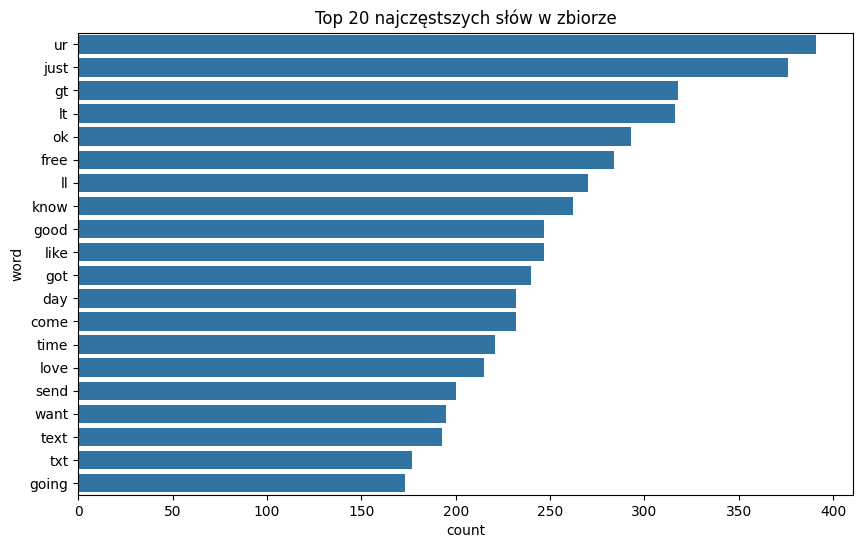

In [92]:
plt.figure(figsize=(10, 6))
sns.barplot(data=word_freq.head(20), x='count', y='word')
plt.title('Top 20 najczęstszych słów w zbiorze')
plt.show()

Widać, że najczęściej występujące słowa to takie, których używa się codzinnie. Najdziemy tu zwykłe wyrazy, jak i skróty używane w języku angielskim. Wyjątkiem są `lt` i `gt` co oznacza `<` i `>` (zostały tak przekształcone przez `CountVectorizer`)

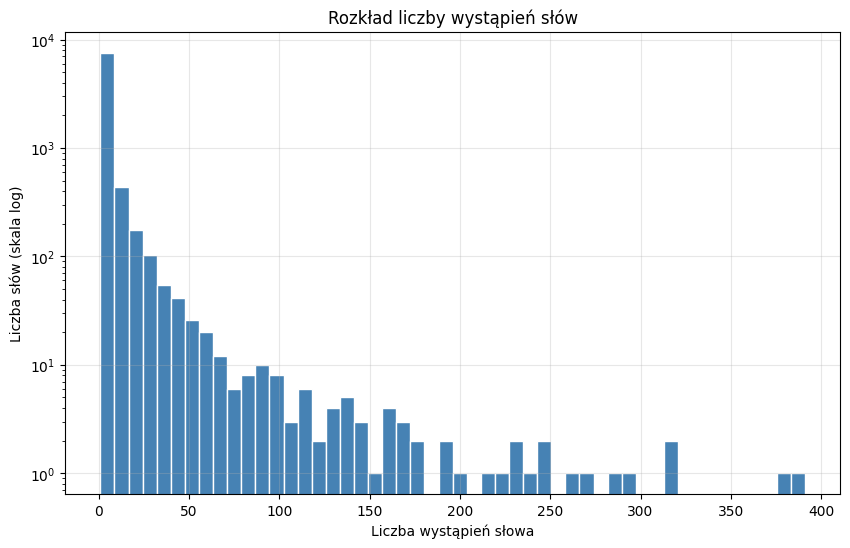

In [93]:
plt.figure(figsize=(10, 6))
plt.hist(word_freq['count'], bins=50, log=True, color='steelblue', edgecolor='white')
plt.xlabel('Liczba wystąpień słowa')
plt.ylabel('Liczba słów (skala log)')
plt.title('Rozkład liczby wystąpień słów')
plt.grid(True, alpha=0.3)
plt.show()

In [94]:
print(f"Liczba unikalnych słów: {len(word_freq)}")
print(f"Słowa występujące tylko raz: {len(word_freq[word_freq['count'] == 1])}")

Liczba unikalnych słów: 8444
Słowa występujące tylko raz: 4384


In [95]:
n_obs = X_counts.shape[0]
n_features = X_counts.shape[1]
total_elements = n_obs * n_features
non_zero = X_counts.nnz
sparsity = (1 - non_zero / total_elements) * 100

print(f"Statystyki macierzy:")
print(f"Liczba dokumentów (n): {n_obs}")
print(f"Liczba cech/słów (p): {n_features}")
print(f"Całkowita liczba komórek: {total_elements}")
print(f"Elementy niezerowe: {non_zero}")
print(f"Rzadkość macierzy: {sparsity:.4f}%")

Statystyki macierzy:
Liczba dokumentów (n): 5572
Liczba cech/słów (p): 8444
Całkowita liczba komórek: 47049968
Elementy niezerowe: 43578
Rzadkość macierzy: 99.9074%


Z analizy macierzy wyszło, że mamy w niej prawie same zera (ponad `99%`). Mimo, iż początkowo może wydawać się to błędne, ma to dużo sensu. Jeśli mamy `5572` wartości w kolumnie, z czego w połowie przypadków jedno pole ma wartość `1`, a `5571` pól ma wartość `0`, to wtedy ma to sens

# Zadanie 2

In [96]:
X = sms['text']
y = sms['is_spam']

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [98]:
pipeline = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('clf', MultinomialNB())
])

In [99]:
parameters = {
    'vect__ngram_range': [(1, 1), (1, 2)],
    'vect__min_df': [1, 2, 5],
    'vect__max_df': [0.7, 0.9],
    'clf__alpha': [0.1, 1.0]
}

grid_search = GridSearchCV(pipeline, parameters, scoring='roc_auc', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...inomialNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__alpha': [0.1, 1.0], 'vect__max_df': [0.7, 0.9], 'vect__min_df': [1, 2, ...], 'vect__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [100]:
print(f"Najlepszy wynik ROC AUC: {grid_search.best_score_:.4f}")
print("Najlepsze parametry:", grid_search.best_params_)

Najlepszy wynik ROC AUC: 0.9880
Najlepsze parametry: {'clf__alpha': 0.1, 'vect__max_df': 0.7, 'vect__min_df': 1, 'vect__ngram_range': (1, 1)}


Po sprawdzeniu różnych opcji przez `GridSearchCV` wyszło, że najlepiej sprawdzają się zwykłe, pojedyncze słowa. Kombinowanie z szukaniem par słów w ogóle nie poprawiło jakości modelu. Wynik na poziomie `0.9880` jest niesamowicie wysoki i będąc szczerym nie spodziewałem tak dobrego wyniku

# Zadanie 3

In [101]:
vect = CountVectorizer(ngram_range=(1,1), min_df=2)
X_train_v = vect.fit_transform(X_train)
X_test_v = vect.transform(X_test)

In [102]:
m_nb = MultinomialNB().fit(X_train_v, y_train)
b_nb = BernoulliNB().fit(X_train_v, y_train)

In [103]:
y_score_m = m_nb.predict_proba(X_test_v)[:, 1]
y_score_b = b_nb.predict_proba(X_test_v)[:, 1]

In [104]:
print(f"Multinomial ROC AUC: {roc_auc_score(y_test, y_score_m):.4f}")
print(f"Bernoulli ROC AUC: {roc_auc_score(y_test, y_score_b):.4f}")

Multinomial ROC AUC: 0.9889
Bernoulli ROC AUC: 0.9942


In [105]:
results = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'multinomial': m_nb.predict(X_test_v),
    'bernoulli': b_nb.predict(X_test_v)
})

In [106]:
results = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'multinomial': m_nb.predict(X_test_v),
    'bernoulli': b_nb.predict(X_test_v)
})

In [107]:
def show_example(title, df):
    if df.empty:
        print(f"\n{title}: brak")
        return
    row = df.iloc[0]
    print(f"\n{title}")
    print(f"tekst: {row['text']}")
    print(f"multinomial: {row['multinomial']}, bernoulli: {row['bernoulli']}, actual: {row['actual']}")

m_mask = (results['actual'] == results['multinomial']) & (results['actual'] != results['bernoulli'])
b_mask = (results['actual'] == results['bernoulli']) & (results['actual'] != results['multinomial'])
m_better = results[m_mask]
b_better = results[b_mask]

show_example("Multinomial lepszy (Bernoulli sie myli)", m_better)
show_example("Bernoulli lepszy (Multinomial sie myli)", b_better)


Multinomial lepszy (Bernoulli sie myli)
tekst: You have 1 new voicemail. Please call 08719181503
multinomial: 1, bernoulli: 0, actual: 1

Bernoulli lepszy (Multinomial sie myli)
tekst: Mathews or tait or edwards or anderson
multinomial: 1, bernoulli: 0, actual: 0


Okazało się, że `BernoulliNB` poradził sobie odrobinę lepiej niż `MultinomialNB`, a oba mają `ROC AUC` równy ponad `0.98`. Rozkład Bernoulliego patrzy tylko na to, czy słowo wystąpiło (1), czy nie (0), a ignoruje to, ile razy padło. W przypadku spamu to ma to dużo sensu – zazwyczaj sam fakt, że w wiadomości jest słowo "FREE" albo "WIN", wystarczy do rozpoznania spamu

# Zadanie 4

In [108]:
class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return X.toarray()

In [109]:
pipe_gauss = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('dense', DenseTransformer()),
    ('clf', GaussianNB())
])


pipe_multi = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('clf', MultinomialNB())
])

In [110]:
pipe_gauss.fit(X_train, y_train)
pipe_multi.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vect', ...), ('tfidf', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [111]:
y_score_g = pipe_gauss.predict_proba(X_test)[:, 1]
y_score_m = pipe_multi.predict_proba(X_test)[:, 1]

print(f"Gaussian NB ROC AUC: {roc_auc_score(y_test, y_score_g):.4f}")
print(f"Multinomial NB ROC AUC: {roc_auc_score(y_test, y_score_m):.4f}")

Gaussian NB ROC AUC: 0.9060
Multinomial NB ROC AUC: 0.9901


Patrząc na wyniki metryki `ROC AUC`, widać sporą różnice między modelami. `MultinomialNB` uzyskał `0.9901`, a `GaussianNB` poradził sobie o wiele gorzej, dając wynik `0.9060`. Nie jest to jednak dziwne, ponieważ rozwiązanie z Gaussem daje lepsze wyniki w przypadku, gdy dane są ciągłe i rozkładem będą przypominać rozkład normalny. W naszym przypadku dane są 0 lub 1 w przypadku `y`, a macierz zliczeń ma wartości całkowite, co nie będzie pasować do Gassowskiego. Nie widzę przypadku, w którym dla tego datasetu rozkład Gaussa byłby dobrym rozwiązaniem

# Zadanie 5

In [112]:
pipe_lr = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('clf', LogisticRegression(solver='liblinear'))
])

param_lr = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2']
}

In [113]:
grid_lr = GridSearchCV(pipe_lr, param_lr, scoring='roc_auc', cv=5)
grid_lr.fit(X_train, y_train)

/Users/blazej/Desktop/Studies/Year 3/Semester 6/Foundations of Machine Teaching/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/blazej/Desktop/Studies/Year 3/Semester 6/Foundations of Machine Teaching/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/blazej/Desktop/Studies/Year 3/Semester 6/Foundations of Machine Teaching/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoi

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 1, ...], 'clf__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [114]:
print(f"Najlepszy ROC AUC dla LogReg: {grid_lr.best_score_:.4f}")
print("Najlepsze parametry:", grid_lr.best_params_)

Najlepszy ROC AUC dla LogReg: 0.9932
Najlepsze parametry: {'clf__C': 100, 'clf__penalty': 'l2'}


Regresja logistyczna dała bardzo dobry wynik, wręcz idealny na poziomie `0.9932`. Nie jest to jednak dziwne, ponieważ nadaje się ona idealnie do klasyfikacji binarnej oraz analizy tekstu (czy jest spam czy nie, czy wiadomość ma odzew pozytwny/negatywny) Dzięki optymalizacji parametru regularyzacji `C`, model ten potrafi efektywnie zarządzać wagami dla tysięcy słów, zmniejszając te mniej istotne. Dodatkowo regularyzacja `L2` pozwala na nie przetrenowanie się modelu

# Zadanie 6

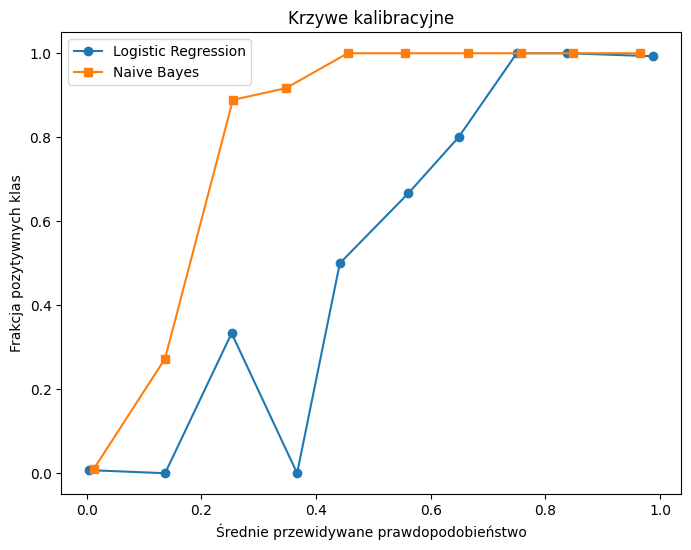

In [115]:
plt.figure(figsize=(8, 6))

probs_lr = grid_lr.predict_proba(X_test)[:, 1]
fop_lr, mpv_lr = calibration_curve(y_test, probs_lr, n_bins=10)
plt.plot(mpv_lr, fop_lr, marker='o', label='Logistic Regression')

probs_nb = pipe_multi.predict_proba(X_test)[:, 1]
fop_nb, mpv_nb = calibration_curve(y_test, probs_nb, n_bins=10)
plt.plot(mpv_nb, fop_nb, marker='s', label='Naive Bayes')

plt.xlabel('Średnie przewidywane prawdopodobieństwo')
plt.ylabel('Frakcja pozytywnych klas')
plt.title('Krzywe kalibracyjne')
plt.legend()
plt.show()

Krzywa kalibracyjna Naiwnego Bayesa świadczy o skłonności modelu do nadmiernej pewności siebie. Wynika to z założenia o niezależności cech – model mnoży wiele prawdopodobieństw warunkowych, przez co wynik końcowy jest bliski 0 lub 1. Regresja logistyczna wypada tu znacznie lepiej, ponieważ jej funkcja logistyczna naturalnie dąży do poprawnego mapowania wyniku na rzeczywiste prawdopodobieństwo wystąpienia klasy

# Zadanie 7

Wybrane n-gramy: ['uk' 'txt']


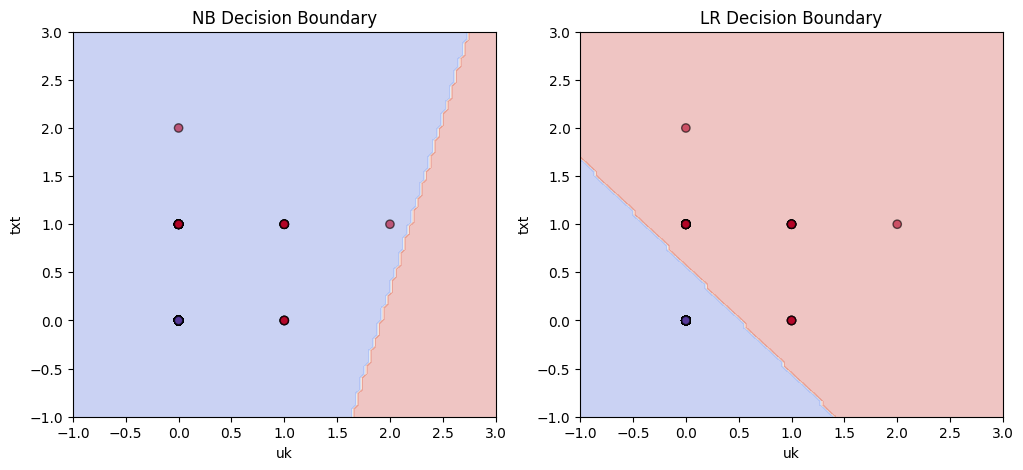

In [ ]:
best_lr = grid_lr.best_estimator_
vect, clf = best_lr.named_steps['vect'], best_lr.named_steps['clf']
top_features = vect.get_feature_names_out()[np.argsort(np.abs(clf.coef_[0]))[-2:]]
print(f"Wybrane n-gramy: {top_features}")

vect_2 = CountVectorizer(vocabulary=top_features)
X_train_2 = vect_2.fit_transform(X_train).toarray()
X_test_2 = vect_2.transform(X_test).toarray()

clf_nb = MultinomialNB().fit(X_train_2, y_train)
clf_lr = LogisticRegression().fit(X_train_2, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, title in zip(axes, [clf_nb, clf_lr], ["NB", "LR"]):
    DecisionBoundaryDisplay.from_estimator(
        model, 
        X_test_2, 
        response_method="predict", 
        alpha=0.3, 
        cmap='coolwarm', 
        ax=ax
    )
    ax.scatter(X_test_2[:, 0], X_test_2[:, 1], c=y_test, edgecolors='k', cmap='coolwarm', alpha=0.6)
    ax.set(title=f"{title} Decision Boundary", xlabel=top_features[0], ylabel=top_features[1])

plt.show()

Wizualizacja dla najlepszych n-gramów pokazuje, że dane mają charakter dyskretny – punkty układają się na regularnej siatce zliczeń. Potwierdza to powód, dlaczego Gaussowski Naiwny Bayes nie zadziałał tutaj aż tak dobrze, jak inne rozwiązania. W wykresie Naiwnego Bayesa widać bardzo poszarpane granice przestrzeni, co świadczy o tym, jak mocno ta metoda jest zależna przez stosunek prawdopodobieństw a priori oraz warunkowych. Granice w przypadku Regresji logistycznej są gładsze, co pokazuje lepsze uogólnienie modelu

# Podsumowanie

Laboratorium to pokazało, jak wielką moc posiadają rozwiązania związane z metodami probabilistycznymi. Warto zauważyć, że od samego początku modele zwracały niesamowicie wysokie wyniki, co jest niespotykanym przypadkiem, żeby proste dobranie parametru tak szybko zwracało niemalże idealny wynik. Porównanie różnych modeli Naiwnego Bayesa pokazało sens doboru odpowiedniej funkcji. Widać, że ma to ogromny wpływ na jakość modelu i dobór nieodpowiedniego rozkładu (w tym przypadku Gaussowskiego) mocno negatywnie wpływa na model

Osobiście zaskoczyła mnie regresja logistyczna, która mimo mojego doświadczenia z nią dała jeszcze lepsze wyniki niż Bayes. Mimo, iż jest to najprostsza metoda z tych z tego laba, to ona okazała się najlepsza (o niewiele, ale też dużo miejsca na poprawę nie było). Zazwyczaj jest tak, że te rozwiązania proste są dobrym baseline do rozwiązania problemu, ale bardziej wyrafinowane metody (jak Bayes) dają o wiele lepsze wyniki. Jednak nie tym razem

Na tak wysokie wyniki wpłynął dobrze zdefiniowany dataset. Jeśli dataset jest dobry, to zawsze jest łatwiej osiągnąć dobre wyniki generalizacji modelu, i tak też było tym razem

Ten lab w bardzo fajny sposób pokazał mi, jak różne rozkłady mocniej lub słabiej wpływają na model budowany o Naiwnego Bayesa oraz pokazały, że nie zawsze warto szukać cięższych rozwiązań, jak np sieci neuronowe, a warto zacząć od łatwiejszych i lżejszych rozwiązań, jak regresja liniowa